# Example training

Requires the run of 2_train_test_splits

## 1. Preparations of the data

In [1]:
from pathlib import Path

artefacts_path = Path("..") / "data" /  "mini_dataset_artifact"
dataset_path = Path("..") / "data" / "mini_dataset"
split_to_use = "ea15dc911b89efb03435a87e27cb6e0bde336c0071a8c1b74c242d6774c7daeb"

In [2]:
import pandas as pd
from lit_ecology_classifier.splitting.split_processor import SplitProcessor

split_processor = SplitProcessor(artefacts_folder= artefacts_path, split_hash= split_to_use)
split_df = split_processor.get_split_df()
split_df.head()

INFO:lit_ecology_classifier.splitting.split_processor:Reloading split based on hash value: ea15dc911b89efb03435a87e27cb6e0bde336c0071a8c1b74c242d6774c7daeb
INFO:lit_ecology_classifier.splitting.split_processor:Path to used split: ../data/mini_dataset_artifact/splits/ea15dc911b89efb03435a87e.csv


,image,class,sha256,date,version_mini,image_path,class_map,split
0,SPC-EAWAG-0P5X-1657469153953175-61976020245260...,keratella_quadrata,2bf0ee058f81569527f44b2902f99eebfff315ef04b66f...,2022-07-10 16:05:53+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,test
1,SPC-EAWAG-0P5X-1529971633256303-1685616084007-...,keratella_quadrata,b51329bb043ea0cbf4e645dbd8b3e2b671212894b0a979...,2018-06-26 00:07:13+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
2,SPC-EAWAG-0P5X-1534593947131228-276543382109-0...,keratella_quadrata,370040c99ac335db709635be9d49dc2d9e95b314fab6d4...,2018-08-18 12:05:47+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
3,SPC-EAWAG-0P5X-1530061231883348-1775213498675-...,keratella_quadrata,358e800d0f731d9bade3bc958cbb04822b2a97af9b7a69...,2018-06-27 01:00:31+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,val
4,SPC-EAWAG-0P5X-1657375349510541-61882217063707...,keratella_quadrata,9b925a9ab1aa0e77493fb77ac73c35fe1358fbaab5ceef...,2022-07-09 14:02:29+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train


In [3]:
class_map = split_processor.get_class_map()
class_map   

{'keratella_quadrata': 2,
 'dinobryon': 1,
 'polyarthra': 3,
 'aphanizomenon': 0,
 'unknown': 4}

## 2. Training the model

THe model training is based on the [Pytorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/) framework. It is a high-level interface for Pytorch that makes it easier to train models on multiple GPUs or Clusters.

### 2.1 LightningDataModule and DataLoaders

Native pytorch dataloaders are used to load the images and labels for the training. The LightningDataModule orchestreat the correct loading of the data and the creation of the dataloaders for training and validation on multiple GPUs.


In [4]:
from lit_ecology_classifier.data.datamodule import DataModule
import logging


datamodule = DataModule(
        datapath= dataset_path,
        dataset = "mini_example",
        batch_size= 32,
        splits= split_df,
        augmentation_level = "low",
        resize_with_proportions = False,
        target_size = 224,

)

datamodule.setup()

INFO:root: Extracting class map from tar file.
INFO:lit_ecology_classifier.helpers.helpers:Extracting class map.
INFO:lit_ecology_classifier.helpers.helpers:Detected directory.
INFO:lit_ecology_classifier.helpers.helpers:Found 5 classes.
INFO:root:Class map: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'unknown': 4}
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 4988
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 831
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 832


### 2.2 Initialize the Model

In [5]:
from lit_ecology_classifier.models.model import LitClassifier

train_out = Path("..") / "train_out"
param_path = Path("..") / "params"

model = LitClassifier(
    train_outpath=train_out,
    main_param_path=param_path,
    class_map = class_map,
    use_wandb=False,
    no_use_multi=False,
    architecture='beitv2',
    add_layer=False,
    finetune=True,
    batch_size=32,
    lr=1e-2,
    lr_factor=0.01,
    loss="cross_entropy",
    testing=False,
    no_TTA=False
)

model.load_datamodule(datamodule)
    

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:lit_ecology_classifier.models.setup_model:Preparing the model using a cached backbone or downloading from huggingface.
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
INFO:root:Model initialized with hyperparameters:
 {'add_layer': False,
 'architecture': 'beitv2',
 'batch_size': 32,
 'class_map': {'aphanizomenon': 0,
               'dinobryon': 1,
               'keratella_quadrata': 2,
             

In [7]:
from lightning.pytorch.loggers import CSVLogger

logger = CSVLogger(save_dir= train_out, name='csv_logs')

### 2.3 Pytorch Lightning Trainer


In [10]:
import os

import torch
import lightning as l
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor


max_epochs = 2


accelerator = "gpu" if torch.cuda.device_count() else "cpu"
devices = torch.cuda.device_count() if "gpu" in accelerator else os.cpu_count() // 4
strategy ="ddp_notebook" if torch.cuda.device_count() > 1 else "auto"

defined_callbacks = [
    pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),
    LearningRateMonitor(logging_interval='step')
    ]


In [11]:
trainer = l.Trainer(
        accelerator= accelerator,
        devices=1,
        logger=logger,
        max_epochs= 2,
        log_every_n_steps=40,
        callbacks=[pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),LearningRateMonitor(logging_interval='step')],
        check_val_every_n_epoch=max(max_epochs // 8,1),
        strategy= strategy,
        default_root_dir=train_out,
    )


MisconfigurationException: `Trainer(strategy='ddp')` is not compatible with an interactive environment. Run your code as a script, or choose a notebook-compatible strategy: `Trainer(strategy='ddp_notebook')`. In case you are spawning processes yourself, make sure to include the Trainer creation inside the worker function.

### 2.4 Train the model

INFO:lit_ecology_classifier.data.datamodule:Train size of df: 4988
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 831
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 832

  | Name  | Type             | Params
-------------------------------------------
0 | model | Beit             | 85.8 M
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
3.8 K     Trainable params
85.8 M    Non-trainable params
85.8 M    Total params
343.063   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Repos\plankton_classifier\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:436: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


{'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'unknown': 4}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


c:\repos\plankton_classifier\lit_ecology_classifier\helpers\modelling_plots.py:117: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
c:\Repos\plankton_classifier\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:436: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


...

Validation: |          | 0/? [00:00<?, ?it/s]

{'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'unknown': 4}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


Validation: |          | 0/? [00:00<?, ?it/s]

{'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'unknown': 4}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


`Trainer.fit` stopped: `max_epochs=2` reached.


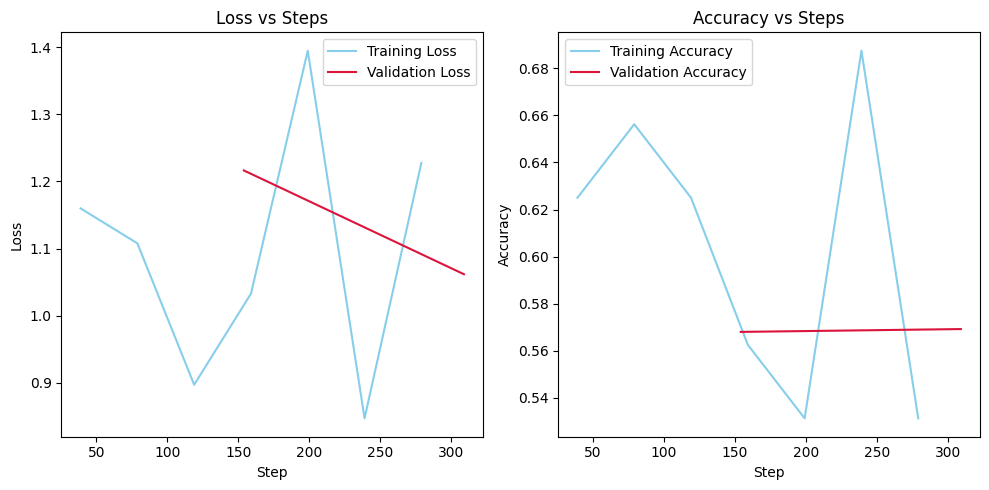

In [9]:
trainer.fit(model, datamodule=datamodule)

rectories to use
    
    parser.add_argument("--train_outpath", default="./train_out", help="Output path for training artifacts")
    parser.add_argument("--main_param_path", default="./params/", help="Main directory where the training parameters are stored")
    parser.add_argument("--use_wandb", action="store_true", help="Use Weights and Biases for logging")
    parser.add_argument("--no_use_multi", action="store_true", help="Use multiple GPUs for training")
    

    # Choose the model architecture
    parser.add_argument('-architecture', choices=['beitv2'],
                            default='beitv2', help='Choose the model architecture')
    
    # additional layers
    parser.add_argument('-add_layer', type=bool, default=False, help='Add additional layers to the model')
    parser.add_argument('-dropout_1', type=float, default=0.4, help='Dropout rate for the first layer')
    parser.add_argument('-dropout_2', type=float, default=0.3, help='Dropout rate for the second layer')
    parser.add_argument('-fc_node', type=int, default=512)

    # Model configuration and training options
    parser.add_argument('--last_layer_finetune', type= bool, default=False)


    # Model configuration and training options
    parser.add_argument("--balance_classes", action="store_true", help="Balance the classes for training")
    parser.add_argument("--batch_size", type=int, default=180, help="Batch size for training")
    parser.add_argument("--max_epochs", type=int, default=20, help="Number of epochs to train")
    parser.add_argument("--lr", type=float, default=1e-2, help="Learning rate for training")
    parser.add_argument("--lr_factor", type=float, default=0.01, help="Learning rate factor for training of full body")
    parser.add_argument("--no_gpu", action="store_true", help="Use no GPU for training, default is False")
    parser.add_argument("--loss", choices=["cross_entropy", "focal"], default="cross_entropy", help="Loss function to use")

    # Augmentation and training/testing specifics
    parser.add_argument("--testing", action="store_true", help="Set this to True if in testing mode, False for training")
    parser.add_argument("--no_TTA", action="store_true", help="Enable Test Time Augmentation")
